## PyTorch Custom Datasets

### Importing necessary libraries and setup device agnostic code

In [1]:
import torch
from torch import nn

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.7.1+cu118


In [2]:
# setup devcie agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Get some data

the custom dataset is a subset of Food101 dataset. no. of images - 10% of Food101 dataset

In [3]:
import requests
import zipfile
from pathlib import Path

# setup a path for the data folder
data_path = Path("data")
image_path = data_path / "pizza_steak_sushi"

# if the folder doesn't exist, download and prepare it
if image_path.is_dir():
        print(f"{image_path} already exists, skipping download...")
        
else:
    print(f"{image_path} does not exist. Downloading the folder...")
    image_path.mkdir(parents=True, exist_ok=True)
    
# Download the data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print(f"Downloading the dataset...")
    f.write(request.content)

# Unzip the data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping the data")
    zip_ref.extractall(image_path)

data\pizza_steak_sushi already exists, skipping download...
Unzipping the data


### Preparing the exploring the data

In [4]:
import os
def walk_through_dir(dir_path):
    """ Walks through dir_path returning its contents"""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in data\pizza_steak_sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\test
There are 0 directories and 25 images in data\pizza_steak_sushi\test\pizza
There are 0 directories and 19 images in data\pizza_steak_sushi\test\steak
There are 0 directories and 31 images in data\pizza_steak_sushi\test\sushi
There are 3 directories and 0 images in data\pizza_steak_sushi\train
There are 0 directories and 78 images in data\pizza_steak_sushi\train\pizza
There are 0 directories and 75 images in data\pizza_steak_sushi\train\steak
There are 0 directories and 72 images in data\pizza_steak_sushi\train\sushi


In [6]:
# setup train and test paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### Visualizing the images

Random image path: data\pizza_steak_sushi\test\sushi\2385731.jpg
Image class: sushi
Image Height: 512
Image width: 512


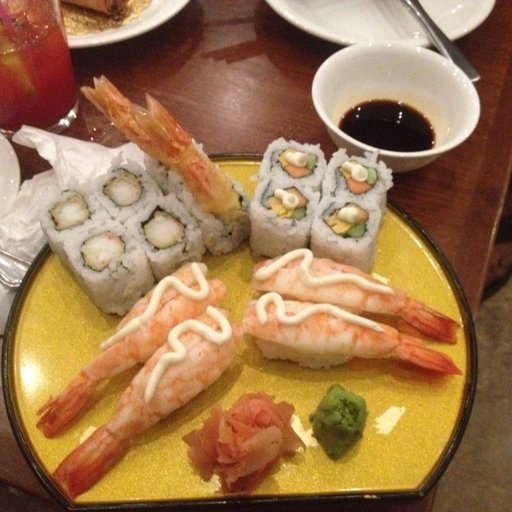

In [7]:
import random
from PIL import Image

# set seed
# random.seed(42)

# 1. get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. pick a random image path
random_image_path = random.choice(image_path_list)
# print(random_image_path)

# 3. get the image class from the path name
image_class = random_image_path.parent.stem
# print(image_class)

# 4. open image
img = Image.open(random_image_path)

# 5. print metadaa
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image Height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

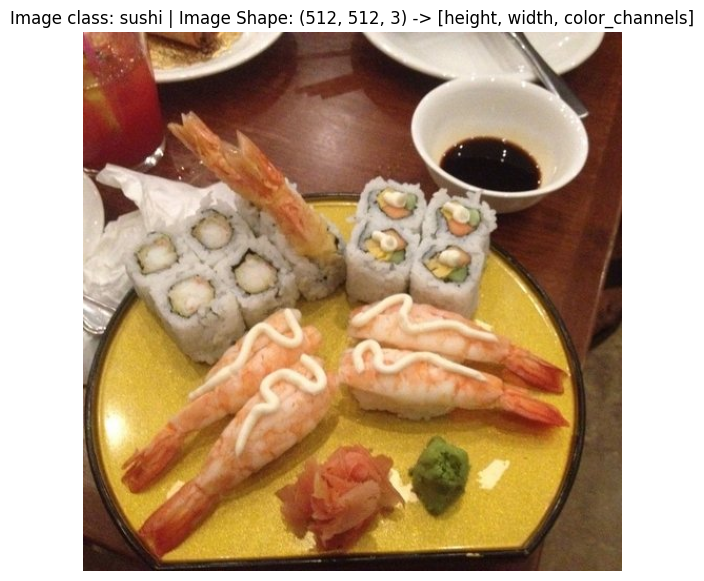

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# turn the image into an array
img_as_array = np.asarray(img)

# plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image Shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

In [9]:
img_as_array

array([[[187, 112, 116],
        [235, 161, 160],
        [231, 158, 151],
        ...,
        [ 75,  27,  23],
        [ 79,  31,  27],
        [ 82,  34,  30]],

       [[179, 103, 107],
        [220, 146, 145],
        [217, 142, 136],
        ...,
        [ 75,  27,  23],
        [ 76,  28,  24],
        [ 78,  30,  26]],

       [[171,  92,  97],
        [200, 124, 124],
        [203, 126, 120],
        ...,
        [ 78,  29,  24],
        [ 78,  29,  24],
        [ 79,  30,  25]],

       ...,

       [[ 54,  37,  30],
        [ 52,  35,  28],
        [ 51,  32,  26],
        ...,
        [101,  80,  51],
        [106,  85,  56],
        [110,  89,  60]],

       [[ 51,  34,  27],
        [ 50,  33,  26],
        [ 48,  31,  24],
        ...,
        [ 99,  78,  51],
        [105,  84,  57],
        [110,  90,  63]],

       [[ 47,  30,  23],
        [ 47,  30,  23],
        [ 46,  29,  22],
        ...,
        [ 98,  77,  50],
        [100,  80,  55],
        [105,  85,  60]]

### Transforming the data

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### Transforming the data with torchvision.trnasforms

In [11]:
# write a transform for image
data_transform = transforms.Compose([
    # resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # flip the images
    transforms.RandomHorizontalFlip(p=0.5),
    # turn the image into a torch tensor
    transforms.ToTensor()
])

In [12]:
data_transform(img)

tensor([[[0.7373, 0.7686, 0.7529,  ..., 0.7216, 0.3255, 0.3176],
         [0.6784, 0.7255, 0.7098,  ..., 0.4941, 0.3020, 0.3294],
         [0.6000, 0.5961, 0.6000,  ..., 0.2980, 0.2980, 0.3216],
         ...,
         [0.1843, 0.2157, 0.1922,  ..., 0.4235, 0.4275, 0.4157],
         [0.1882, 0.1804, 0.1804,  ..., 0.4235, 0.4275, 0.4157],
         [0.1843, 0.1882, 0.1804,  ..., 0.4157, 0.4275, 0.4157]],

        [[0.4275, 0.5098, 0.4824,  ..., 0.6314, 0.1608, 0.1255],
         [0.3098, 0.4314, 0.4078,  ..., 0.3647, 0.1294, 0.1373],
         [0.2667, 0.2941, 0.3255,  ..., 0.1451, 0.1216, 0.1333],
         ...,
         [0.1020, 0.1294, 0.1098,  ..., 0.3255, 0.3412, 0.3294],
         [0.1020, 0.1059, 0.1098,  ..., 0.3176, 0.3216, 0.3216],
         [0.1098, 0.1020, 0.0941,  ..., 0.3176, 0.3176, 0.3137]],

        [[0.3765, 0.3686, 0.3412,  ..., 0.5647, 0.1137, 0.0863],
         [0.3294, 0.3216, 0.2667,  ..., 0.3098, 0.0745, 0.0706],
         [0.2706, 0.2627, 0.2275,  ..., 0.1020, 0.0863, 0.

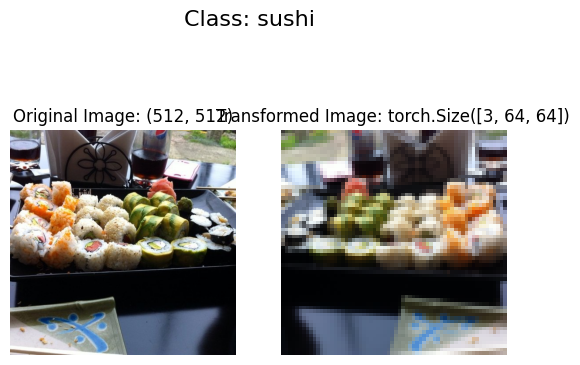

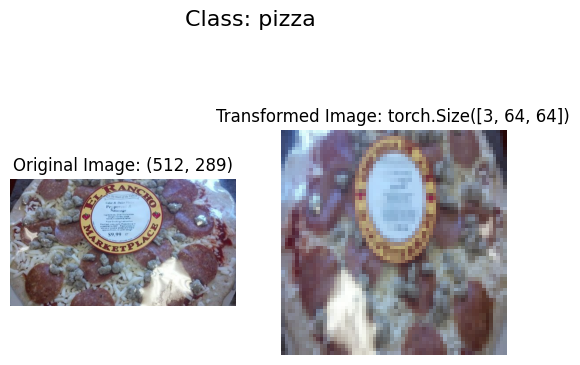

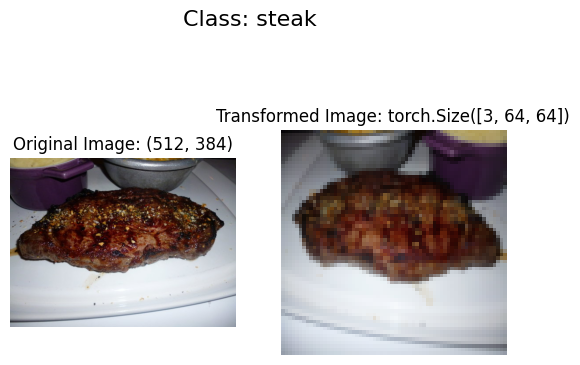

In [13]:
def plot_transformed_images(image_paths:list, transform, n=3, seed=None):
    # random.seed(42)
    
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original Image: {f.size}")
            ax[0].axis(False)
            
            # Transform and plot target image
            transformed_image = transform(f) # Note: we will need to change the shape for matplotlib 
            ax[1].imshow(transformed_image.permute(1, 2, 0)) # (C, H, w) -> (H, W, C)
            ax[1].set_title(f"Transformed Image: {transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)


### Option 1: Loading image data using `ImageFolder`

In [14]:
# Use ImageFolder to create datasets
from torchvision import datasets
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform, # transform for the data
    target_transform=None # transform for the labels/target
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform
)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [15]:
# get class names as a list
class_names = train_data.classes

# class names as a dictionary
class_dict = train_data.class_to_idx

print(f"Class Names: {class_names}\nClass Dictionary: {class_dict}")

Class Names: ['pizza', 'steak', 'sushi']
Class Dictionary: {'pizza': 0, 'steak': 1, 'sushi': 2}


In [16]:
# Check the length of the dataset
len(train_data), len(test_data)

(225, 75)

In [17]:
# Index on the train_data dataset to get a single image and a label
img, label = train_data[0][0], train_data[0][1]
print(f"Image Shape: {img.shape}\nImage Datatype: {img.dtype}")
print(f"Label Index: {label}\nLabel Name: {class_names[label]}\nLabel Datatype: {type(label)}")

Image Shape: torch.Size([3, 64, 64])
Image Datatype: torch.float32
Label Index: 0
Label Name: pizza
Label Datatype: <class 'int'>


original Shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image Permute: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

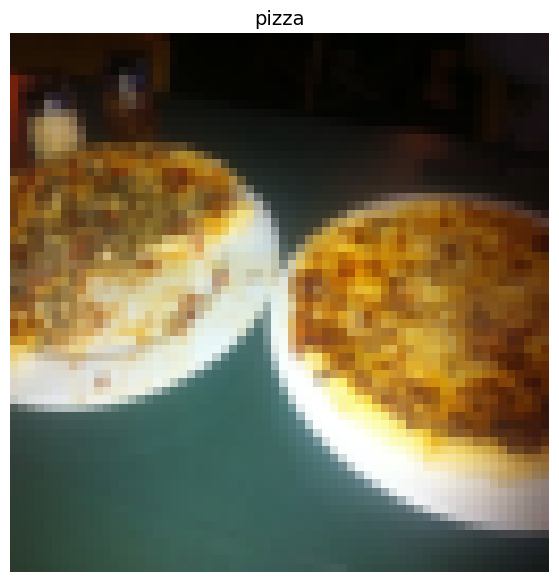

In [18]:
# Rearrange the dimensions
img_permute = img.permute(1, 2, 0)

# print the different shapes
print(f"original Shape: {img.shape} -> [color_channels, height, width]")
print(f"Image Permute: {img_permute.shape} -> [height, width, color_channels]")

# plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(class_names[label], fontsize=14)

#### Turn loaded images into dataloaders

In [19]:
import os
os.cpu_count()

16

In [20]:
# turn train and test data into dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    num_workers=os.cpu_count(),
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    num_workers=os.cpu_count(),
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2dba9282d50>,
 <torch.utils.data.dataloader.DataLoader at 0x2dba91c89d0>)

In [21]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [22]:
img, label = next(iter(train_dataloader))

# Batch size will now be 32
print(f"Image Shape: {img.shape} -> [batch_size, color_channels, width]")
print(f"Label Shape: {label.shape}")

Image Shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, width]
Label Shape: torch.Size([32])


### Option 2: Loading the image data with a custom `Dataset`

In [23]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List


In [24]:
# Instance of torchvision.datasets.ImageFolder
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

#### Creating a helper function to get a class name

In [26]:
# setup a path for target directory
target_directory = train_dir
print(f"Target Dir: {target_directory}")

# get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target Dir: data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [27]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    # 1. get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. raise an error if class names are not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}. Please check file structure")


    # 3. create a dictionary of index labels (computers prefer numbers rather than the strings as labels)
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

    return classes, class_to_idx

In [28]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})